# Burgers' equation

Solve the viscous Burgers equation

$$u_t + u\,u_x - \nu\,u_{xx} = 0,\qquad x\in(-1,1),\ t\in(0,1),\qquad u(x,0)=-\sin(\pi x)$$

with a physics-informed neural network.

Requires the `pinn` package.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import jax
import jax.numpy as jnp

import pinn
from pinn import operators as op, sampling

%matplotlib inline

# Burgers is trained in single precision; keep matmuls in float32.
jax.config.update("jax_default_matmul_precision", "float32")

## Define the problem

A problem supplies its residual functions and matching samplers. Coordinates are
`[x, t]`; `operators.grad`/`grad2` take derivatives of a scalar field, and the
`sampling` helpers return collocation points over the domain. The initial
condition is enforced against a target carried in the last coordinate — supplied
by `analytical_ic` on the first slab and by the previous slab afterwards.

In [ ]:
X, T = 0, 1  # coordinate indices


class BurgersProblem(pinn.Problem):
    """u_t + u u_x - nu u_xx = 0 on (-1, 1) x (0, 1)."""

    x_min, x_max, t_max = -1.0, 1.0, 1.0
    nu = 0.01
    problem_name = "Burgers"
    ref_path = pinn.reference_path("burgers")

    def __init__(self, *, n_pde, n_ic, n_bc=0):
        self.n_pde, self.n_ic, self.n_bc = n_pde, n_ic, n_bc

    def residual_fns(self):
        return {"pde": self.pde_residual, "ic": self.ic_residual}

    def pde_residual(self, model, coords):
        _u = lambda c: model(c)[0]
        
        u = _u(coords)
        ut = op.grad(_u, coords, T)
        ux = op.grad(_u, coords, X)
        uxx = op.grad2(_u, coords, X)
        
        return jnp.array([ut + u * ux - self.nu * uxx])

    def ic_residual(self, model, coords):
        # coords = [x, t, u_target]; enforce u(x, t) = u_target.
        return jnp.array([model(coords[:2])[0] - coords[2]])

    def samplers(self):
        return {
            "pde": sampling.interior(self.x_min, self.x_max),
            "ic":  sampling.initial_line(self.x_min, self.x_max),
        }

    def analytical_ic(self, x):
        return -jnp.sin(jnp.pi * x)

## Configure the run

`RunConfig` holds every setting: the network, number of collocation points,
sketch sizes, and initial condition weighting, and how many time intervals to
break the problem down into.

In [3]:
cfg = pinn.RunConfig(
    dt=1.0,
    network=lambda key: pinn.MLP(
        key, BurgersProblem,
        hidden_dims=(20, 20, 20, 20),
        periodic_bc=True, n_inputs=2, n_outputs=1,
    ),
    n_pde=2**15,
    n_ic=2**14,
    residual_sketch=800,
    parameter_sketch=800,
    batch_size=2**14,
    probe_batch_size=2**10,
    pde_weight=1e-2,
    target_rho=0.15  # particularly aggressive
)

## Train

Precompiling should take less than 2 minutes.
(Doesn't remove all future compiling - but it helps.)

In [8]:
pinn.precompile32(BurgersProblem, cfg)

[MLP] periodic [cos/sin + t] | 20→20→20→20→1 | 1,365 params


Then training should be fast.

Problem: Burgers
Slabs: 1  (dt=1.000)
[MLP] periodic [cos/sin + t] | 20→20→20→20→1 | 1,365 params
Reference: /home/webb/physics-informed-neural-networks/src/pinn/references/burgers.npz — 102400 eval points in 2D, channels ['u'], plot x×t (1024×100)


Image(value=b'', layout="Layout(max_width='1600px', width='100%')")


────────────────────────────────────────────────────────────
  Slab (t=0.0000→1.0000) (float32)
────────────────────────────────────────────────────────────
Compile complete: 11.49s

────────────────────────────────────────────────────────────
  Slab (t=0.0000→1.0000) (float32)
────────────────────────────────────────────────────────────
  radius below threshold — moving to next slab.
  solved up to t=1.00 | final rel error = 3.920e-07, compute time = 15.63s
[MLP] periodic [cos/sin + t] | 20→20→20→20→1 | 1,365 params


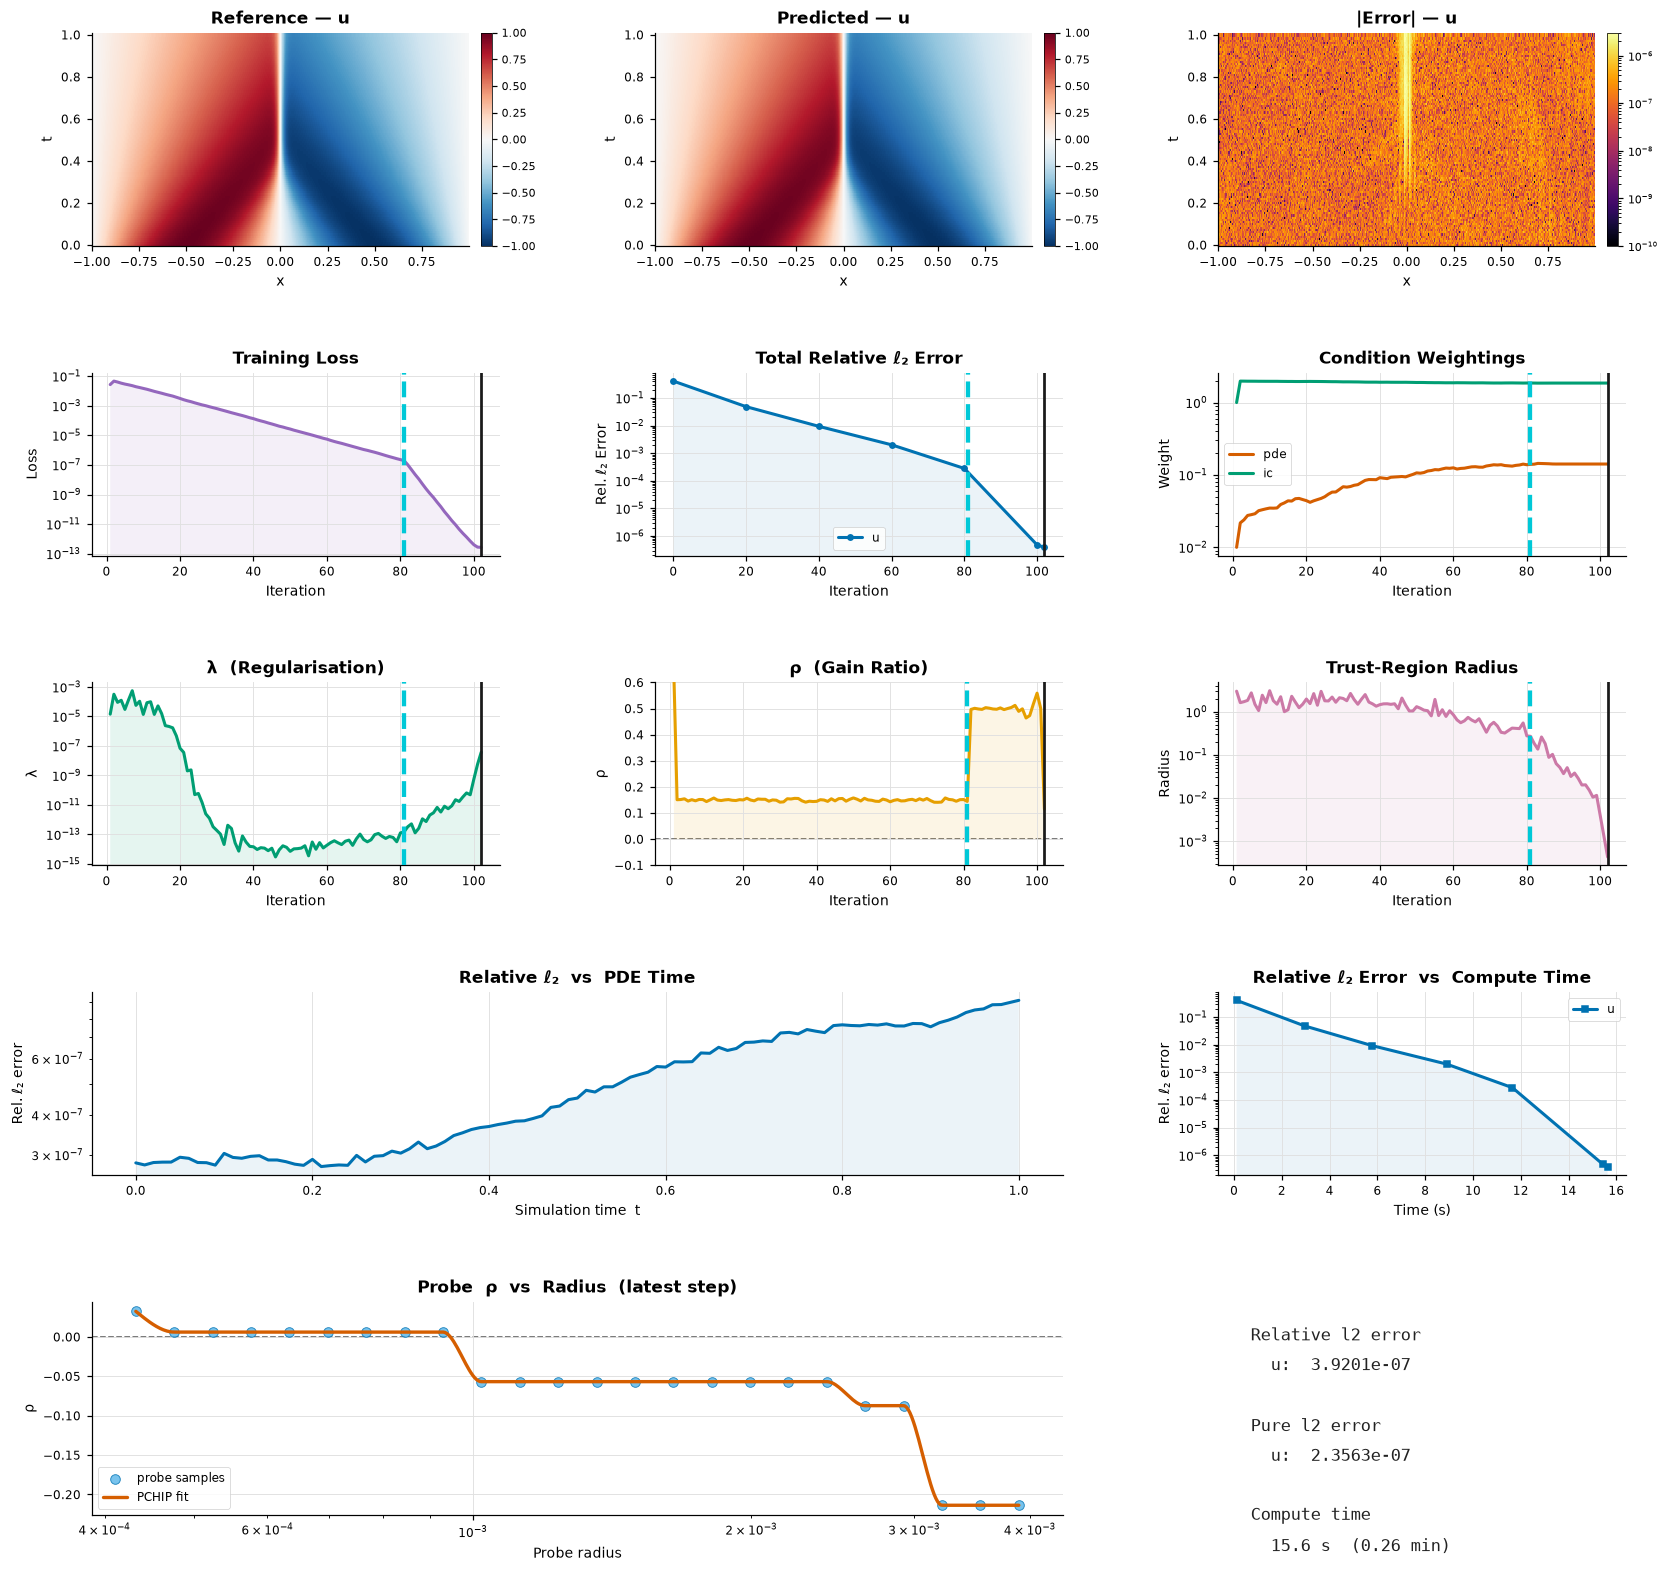

In [9]:
results = pinn.train32(BurgersProblem, cfg)

## Results

The reference is a pseudo-spectral solution (`scripts/generate_references.py`).
The panels show the PINN solution and its error, the relative $\ell_2$ error
against wall time and simulation time, and the optimiser's internal history
(loss, condition weights, step-quality ratio $\varrho$, regularisation $\lambda$, and trust-region radius $\Delta$).

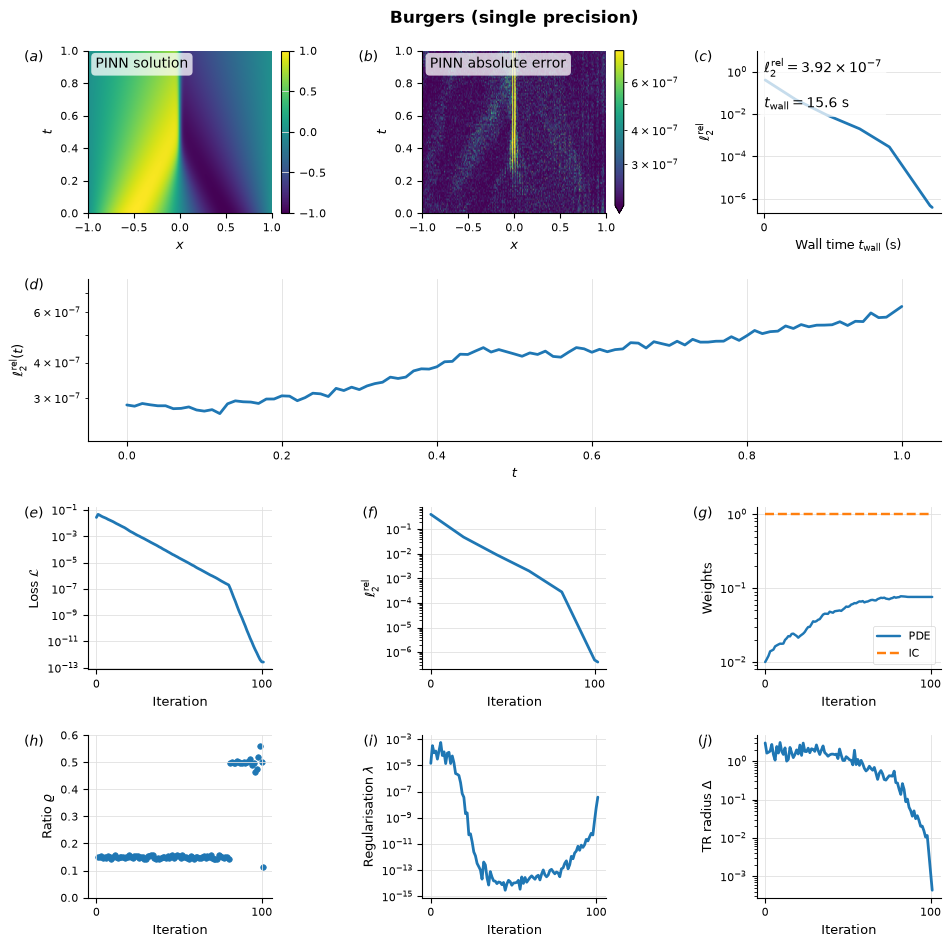

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm


def attach_cbar(fig, ax, im, **kw):
    fig.canvas.draw()
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.008, pos.y0, 0.008, pos.height])
    cb = fig.colorbar(im, cax=cax, **kw)
    cb.ax.tick_params(labelsize=8)
    return cb


def panel_label(ax, label):
    fig = ax.get_figure()
    fig.canvas.draw()
    pos = ax.get_position()
    fig.text(pos.x0 - 0.04, pos.y1, label, transform=fig.transFigure,
             ha="right", va="top")


coords = np.array(results["all_coords"])
t_col = np.array(results["t_col"])
xs = np.unique(coords[:, 0])
ts = np.unique(t_col)
nt, nx = len(ts), len(xs)

U_pred = np.array(results["slabs"][-1]["u_pred"]).T.ravel().reshape(nx, nt).T
U_ref = np.array(results["u_ref_flat"]).T.ravel().reshape(nx, nt).T

iters = np.arange(len(results["hists"]["loss"]))
loss_h = np.array(results["hists"]["loss"])
lam_h = np.array(results["hists"]["lambda"])
rho_h = np.array(results["hists"]["rho"])
rad_h = np.array(results["hists"]["radius"])

w_stack = np.stack([results["weight_hists"]["pde"],
                    results["weight_hists"]["ic"]], axis=1)
w_stack = w_stack / w_stack.max(axis=1, keepdims=True)
w_pde_h, w_ic_h = w_stack[:, 0], w_stack[:, 1]

l2_wall_t = np.array([x[0] for x in results["l2_rel_wall"]])
l2_wall_v = np.array([x[1]["u"] for x in results["l2_rel_wall"]])
l2_iter_t = np.array([x[0] for x in results["l2_rel_iter"]])
l2_iter_v = np.array([x[1]["u"] for x in results["l2_rel_iter"]])

rel_l2_global = np.linalg.norm(U_pred - U_ref) / np.linalg.norm(U_ref)
t_total_final = results["l2_rel_wall"][-1][0]

denom = np.sqrt(np.mean(U_ref**2, axis=1)) + 1e-16
l2_vs_t = np.sqrt(np.mean((U_pred - U_ref)**2, axis=1)) / denom
lo, hi = l2_vs_t.min() / 1.25, l2_vs_t.max() * 1.25

fig, axes = plt.subplot_mosaic(
    [["A", ".", "B", ".", "C"],
     [".", ".", ".", ".", "."],
     ["D", "D", "D", "D", "D"],
     [".", ".", ".", ".", "."],
     ["E", ".", "F", ".", "G"],
     [".", ".", ".", ".", "."],
     ["H", ".", "I", ".", "J"]],
    figsize=(11, 11),
    height_ratios=[1, 0.15, 1, 0.15, 1, 0.15, 1],
    width_ratios=[1, 0.5, 1, 0.5, 1],
)

# (a) PINN solution
ax = axes["A"]
abs_max = float(np.nanmax(np.abs(U_ref)))
im0 = ax.imshow(U_pred, vmin=-abs_max, vmax=abs_max, aspect="auto",
                origin="lower", extent=[xs[0], xs[-1], ts[0], ts[-1]],
                rasterized=True)
ax.set(xlabel="$x$", ylabel="$t$", xlim=[-1.0, 1.0]); ax.grid(False)
ax.text(0.04, 0.96, r"$\mathrm{PINN\ solution}$", transform=ax.transAxes,
        ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.75))
panel_label(ax, "$(a)$"); attach_cbar(fig, ax, im0)

# (b) Absolute error
ax = axes["B"]
im1 = ax.imshow(np.abs(U_pred - U_ref) + 1e-18, norm=LogNorm(vmin=lo, vmax=hi),
                aspect="auto", origin="lower",
                extent=[xs[0], xs[-1], ts[0], ts[-1]], rasterized=True)
ax.set(xlabel="$x$", ylabel="$t$", xlim=[-1.0, 1.0]); ax.grid(False)
exp = int(np.floor(np.log10(rel_l2_global)))
coeff = rel_l2_global / 10**exp
ax.text(0.04, 0.96, r"$\mathrm{PINN\ absolute\ error}$", transform=ax.transAxes,
        ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.75))
panel_label(ax, "$(b)$"); attach_cbar(fig, ax, im1, extend="min")

# (c) Relative L2 vs wall time
ax = axes["C"]
ax.semilogy(l2_wall_t, l2_wall_v, lw=2, solid_capstyle="round")
ax.set(xlabel=r"Wall time $t_{\rm wall}$ (s)", ylabel=r"$\ell^{\mathrm{rel}}_2$")
ax.text(0.04, 0.96,
        rf"$\ell^{{\mathrm{{rel}}}}_2 = {coeff:.2f}\times10^{{{exp}}}$" + "\n\n"
        + rf"$t_{{\rm wall}} = {t_total_final:.1f}\ \mathrm{{s}}$",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.75))
panel_label(ax, "$(c)$"); ax.set_ylim(lo, 1e1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (d) Relative L2 vs simulation time
ax = axes["D"]
ax.semilogy(ts, l2_vs_t, lw=2, solid_capstyle="round")
ax.set(xlabel="$t$", ylabel=r"$\ell^{\mathrm{rel}}_2(t)$", ylim=[lo, hi])
panel_label(ax, "$(d)$")

# (e) Loss vs iteration
ax = axes["E"]
ax.semilogy(iters, loss_h, lw=2, solid_capstyle="round")
ax.set(xlabel="Iteration", ylabel=r"Loss $\mathcal{L}$")
panel_label(ax, "$(e)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (f) Relative L2 vs iteration
ax = axes["F"]
ax.semilogy(l2_iter_t, l2_iter_v, lw=2, solid_capstyle="round")
ax.set(xlabel="Iteration", ylabel=r"$\ell^{\mathrm{rel}}_2$")
panel_label(ax, "$(f)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (g) Condition weights
ax = axes["G"]
ax.semilogy(iters, w_pde_h, lw=1.75, label="PDE", solid_capstyle="round")
ax.semilogy(iters, w_ic_h, lw=1.75, label="IC", solid_capstyle="round", ls="--")
ax.set(xlabel="Iteration", ylabel="Weights")
ax.legend(fontsize=8, framealpha=0.8, loc="lower right")
panel_label(ax, "$(g)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (h) Step-quality ratio
ax = axes["H"]
ax.scatter(iters, rho_h)
ax.set(xlabel="Iteration", ylabel=r"Ratio $\varrho$", ylim=[0.0, 0.6])
panel_label(ax, "$(h)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (i) Regularisation
ax = axes["I"]
ax.semilogy(iters, lam_h, lw=2, solid_capstyle="round")
ax.set(xlabel="Iteration", ylabel=r"Regularisation $\lambda$")
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
panel_label(ax, "$(i)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# (j) Trust-region radius
ax = axes["J"]
ax.semilogy(iters, rad_h, lw=2, solid_capstyle="round")
ax.set(xlabel="Iteration", ylabel=r"TR radius $\Delta$")
panel_label(ax, "$(j)$")
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

axes["B"].set_title("Burgers (single precision)", pad=20, fontsize=12)
plt.show()